In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [54]:
df=pd.read_csv("d:\python\dirty_cafe_sales.csv")
print (df.shape)


(10000, 8)


In [55]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [57]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [58]:
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [59]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [81]:
df.replace(["UNKNOWN","ERROR"], pd.NA, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [82]:
df.dropna()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03
...,...,...,...,...,...,...,...,...
9975,TXN_9668108,Cake,1.0,3.0,3.0,Cash,In-store,2023-01-20
9979,TXN_9933628,Smoothie,5.0,4.0,20.0,Cash,In-store,2023-07-20
9986,TXN_2858441,Sandwich,2.0,4.0,8.0,Credit Card,In-store,2023-12-14
9991,TXN_3897619,Sandwich,3.0,4.0,12.0,Cash,Takeaway,2023-02-24


In [84]:
df.fillna("2")

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,2,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,2,2,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,2,2,2023-08-30
9996,TXN_9659401,2,3.0,2,3.0,Digital Wallet,2,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,2,2023-03-02
9998,TXN_7695629,Cookie,3.0,2,3.0,Digital Wallet,2,2023-12-02


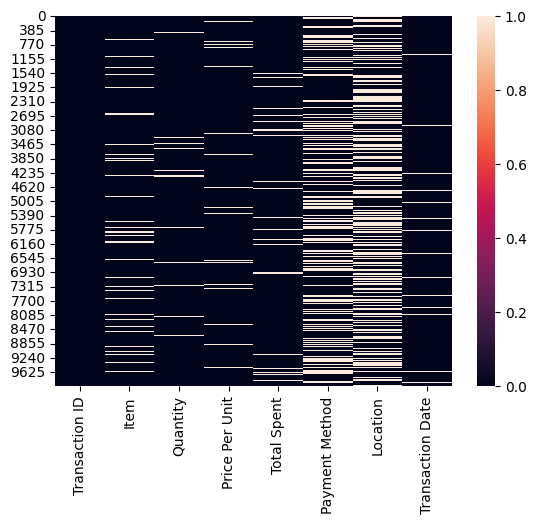

In [85]:
plt.Figure(figsize=(10,5))
sns.heatmap(df.isnull())
plt.show()

In [61]:
df.isnull().keys()

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [62]:
null_var=df.isnull().sum()/df.shape[0]*100
null_var

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

In [63]:
drop_column=null_var[null_var>12].keys()


In [64]:
drop_column

Index(['Payment Method', 'Location'], dtype='str')

In [65]:
df2_drop_col=df.drop(columns=drop_column)
df2_drop_col

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,2023-06-11
...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,2023-12-02


<Axes: >

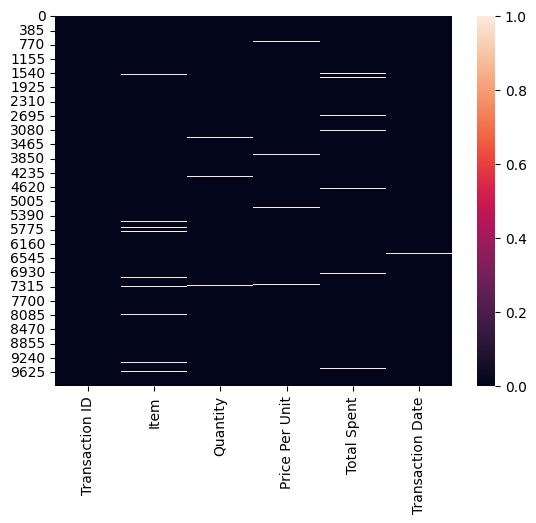

In [66]:
sns.heatmap(df2_drop_col.isnull())


In [67]:
drop_column=null_var[null_var>12].keys()


<Axes: >

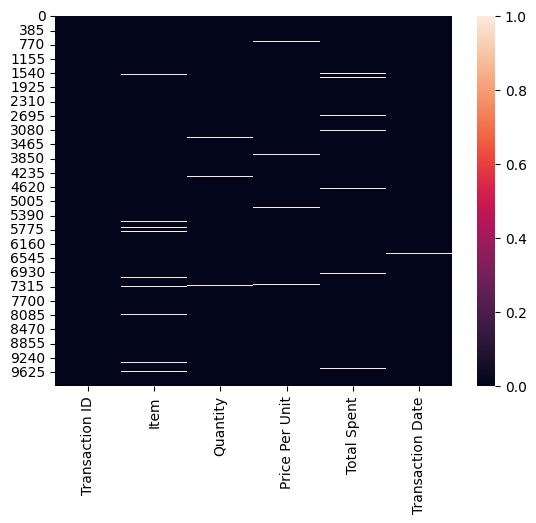

In [68]:
sns.heatmap(df2_drop_col.isnull())


In [69]:
threshold = 0.5 * len(df)
df = df.dropna(thresh=threshold, axis=1)

In [70]:
df['Price Per Unit'] = df['Price Per Unit'].astype(str).str.replace('$','')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')

In [87]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [71]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [88]:
df['Transaction ID'] = pd.to_datetime(df['Transaction ID'], errors='coerce')

In [72]:
df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)

0       2.0
1       4.0
2       4.0
3       2.0
4       2.0
       ... 
9995    2.0
9996    3.0
9997    4.0
9998    3.0
9999    3.0
Name: Quantity, Length: 10000, dtype: float64

In [73]:
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)

0       2.0
1       4.0
2       4.0
3       2.0
4       2.0
       ... 
9995    2.0
9996    3.0
9997    4.0
9998    3.0
9999    3.0
Name: Quantity, Length: 10000, dtype: float64

In [76]:
df['Payment Method'].fillna(df['Payment Method'].mode()[0], inplace=True)

0          Credit Card
1                 Cash
2          Credit Card
3              UNKNOWN
4       Digital Wallet
             ...      
9995    Digital Wallet
9996    Digital Wallet
9997    Digital Wallet
9998    Digital Wallet
9999              Cash
Name: Payment Method, Length: 10000, dtype: str

In [ ]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [ ]:
outliers = df[(df['Quantity'] < lower) | (df['Quantity'] > upper)]

In [ ]:
pd.get_dummies(df['Payment Method'])

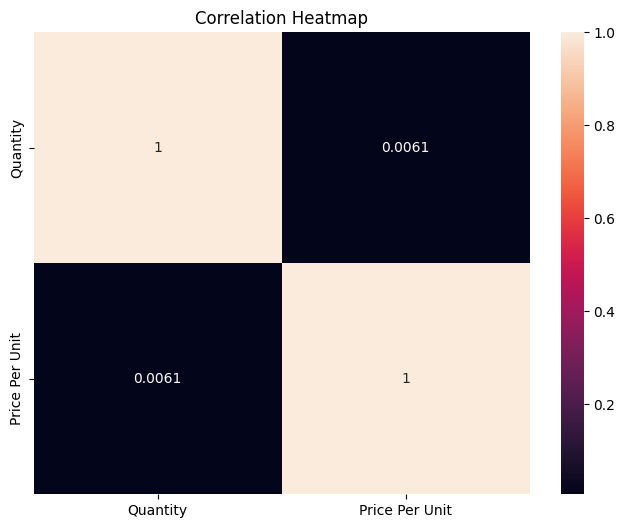

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()